In [1]:
import pyterrier as pt
import matplotlib.pyplot as plt
import pandas as pd
import os
from ir_measures import *

run_dir = "../runs/"

In [2]:
docs = pd.read_pickle("/nfs/primary/sas_reranker/ohsumed_docs_w_t5base_sensitivity.pkl")
queries = pd.read_pickle("/nfs/primary/graph_adaptive_reranking/queries.pkl")
qrels = pd.read_pickle("/nfs/primary/graph_adaptive_reranking/qrels.pkl")

In [3]:
# tilde_baseline = pt.io.read_results("./runs/tilde_baseline")
# splade_max_baseline = pt.io.read_results("./runs/splade_max_baseline")

# def filter(run):
#     run = pd.merge(run, docs, on = "docno")
#     run = run[run["t5_sensitivity"] == 0]
#     run = run.drop("rank", axis = 1)
#     run = pt.model.add_ranks(run)
#     return run

# tilde_filter_pipeline = tilde_baseline >> pt.apply.generic(filter)
# splade_max_filter_pipeline = splade_max_baseline >> pt.apply.generic(filter)

# pt.io.write_results(tilde_filter_pipeline(queries), "./runs/tilde_filter_baseline")
# pt.io.write_results(splade_max_filter_pipeline(queries), "./runs/splade_max_filter_baseline")

In [4]:
run_files = [pt.io.read_results(f"{run_dir}/{f}") for f in os.listdir(run_dir) if not f.endswith("checkpoints") and "baseline" not in f]
run_names = [f for f in os.listdir(run_dir) if not f.endswith("checkpoints") and "baseline" not in f]

In [5]:
baseline_run_files = [pt.io.read_results(f"{run_dir}/{f}") for f in os.listdir(run_dir) if "baseline" in f]
baseline_run_names = [f for f in os.listdir(run_dir) if "baseline" in f]

In [6]:
rq2_run_files = [pt.io.read_results(f"../rq2/runs/{f}") for f in os.listdir("../rq2/runs") if "baseline" in f]
rq2_run_names = [f for f in os.listdir("../rq2/runs/") if "baseline" in f]

In [7]:
rq3_run_files = [pt.io.read_results(f"./runs/{f}") for f in os.listdir("./runs") if "checkpoints" not in f]
rq3_run_names = [f for f in os.listdir("./runs/") if "checkpoints" not in f]

In [8]:
def _sens_docs(qrels, run):
    if "sensitivity" in run.columns:
        run = run.drop(columns = ["sensitivity"])
    merged = pd.merge(run, docs, left_on = "doc_id", right_on = "docno")
    return merged.sensitivity.sum()
    
import ir_measures
sens_docs = ir_measures.define_byquery(
    _sens_docs, 
    name="sens_docs")

In [9]:
retrieval_results = pt.Experiment(
    run_files,
    queries,
    qrels,
    eval_metrics=[nDCG@10, sens_docs@10],
    names = run_names
)

baseline_retrieval_results = pt.Experiment(
    baseline_run_files,
    queries,
    qrels,
    eval_metrics=[nDCG@10, sens_docs@10],
    names = baseline_run_names
)

rq2_retrieval_results = pt.Experiment(
    rq2_run_files,
    queries,
    qrels,
    eval_metrics=[nDCG@10, sens_docs@10],
    names = rq2_run_names
)

rq3_retrieval_results = pt.Experiment(
    rq3_run_files,
    queries,
    qrels,
    eval_metrics=[nDCG@10, sens_docs@10],
    names = rq3_run_names
)

In [10]:
rq3_retrieval_results

,name,nDCG@10,sens_docs@10
0,unicoil_strategy3_distil,0.430331,0.990566
1,unicoil_strategy2_distil,0.331773,0.481132
2,tilde_strategy3_distil,0.453312,1.018868
3,tilde_strategy1_distil,0.310047,0.754717
4,unicoil_strategy1_distil,0.299743,0.716981
5,tilde_strategy2_distil,0.359594,0.481132
6,splade_max_strategy2_distil,0.000370,0.000000
7,splade_max_strategy1_distil,0.234933,0.490566
8,splade_max_strategy3_distil,0.412674,0.971698


In [11]:
# Extract model prefixes and group sizes from 'name'
retrieval_results['model'] = retrieval_results['name'].str.extract(r"^(splade_max|tilde|unicoil)")
retrieval_results['group'] = retrieval_results['name'].str.extract(r"(group\d+)")
retrieval_results = retrieval_results.dropna()
retrieval_results['strategy'] = retrieval_results['name'].str.extract(r"(strategy\d+)")

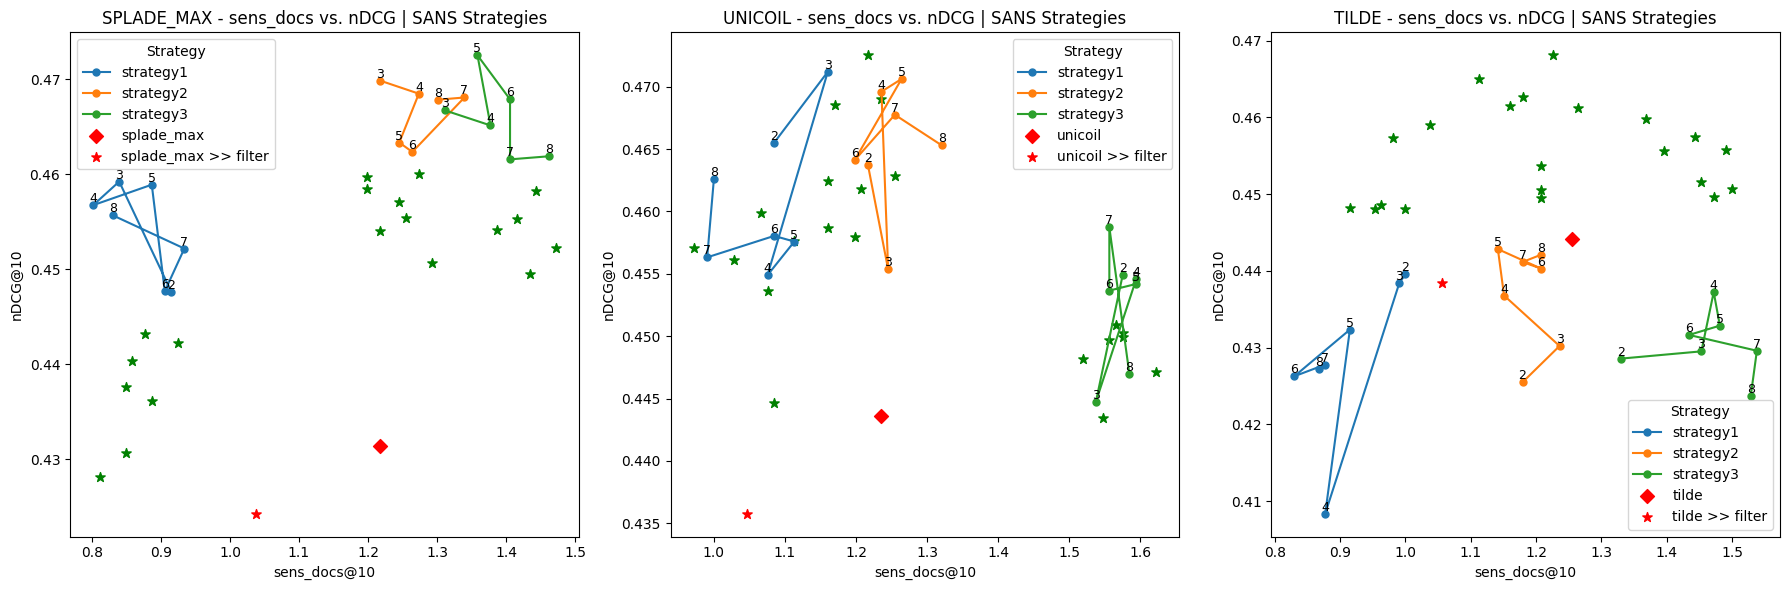

In [12]:
# Filter the dataframe by model types
models = ['splade_max', 'unicoil', 'tilde']

# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Loop through each model
for idx, model in enumerate(models):
    # Filter data for the current model
    model_data = retrieval_results[retrieval_results['model'] == model]
    
    # Loop through each strategy and plot
    for strategy in ['strategy1', 'strategy2', 'strategy3']:
        # Filter data for the current strategy
        strategy_data = model_data[model_data['strategy'] == strategy]
        
        # Group the data by the 'group' column, which indicates the group size (e.g., group2, group3, etc.)
        group_sizes = sorted(strategy_data['group'].unique(), key=lambda x: int(x.replace('group', '')))
        
        # Prepare x and y values for plotting
        nDCG_values = []
        sens_docs_values = []
        group_labels = []  # For labeling group sizes

        for group_size in group_sizes:
            group_data = strategy_data[strategy_data['group'] == group_size]
            # Use the raw values for each group size
            nDCG_values.extend(group_data['nDCG@10'].values)
            sens_docs_values.extend(group_data['sens_docs@10'].values)
            group_labels.extend([group_size] * len(group_data))  # Add the group label for each point
        
        # Plot the individual data points for this strategy
        axes[idx].plot(sens_docs_values, nDCG_values, label=strategy, marker='o', linestyle='-', markersize=5)
        
        # Add labels for the group sizes at the x-axis positions
        for i, group_label in enumerate(group_labels):
            group_label = group_label.split("group")[1]
            axes[idx].text(sens_docs_values[i], nDCG_values[i], group_label, fontsize=9, ha='center', va='bottom')
    
    # Add baseline points
    baseline_points = baseline_retrieval_results[baseline_retrieval_results['name'].str.contains(model)]
    for _, row in baseline_points.iterrows():
        # Determine the label (MODEL or MODEL >> FILTER)
        if "filter" in row['name']:
            label = f"{model} >> filter"
            marker = "*"
        else:
            label = f"{model}"
            marker = "D"
        
        # Plot the baseline point
        axes[idx].scatter(row['sens_docs@10'], row['nDCG@10'], color='red', marker=marker, s=50, label=label)
        # axes[idx].text(row['sens_docs@10'], row['nDCG@10'] + 0.001, label, fontsize=9, color='red', ha='center', va='bottom')


    rq2_points = rq2_retrieval_results[rq2_retrieval_results['name'].str.contains(model)]
    for _, row in rq2_points.iterrows():
        axes[idx].scatter(row['sens_docs@10'], row['nDCG@10'], color='green', marker=marker, s=50)
        
    # Set titles and labels for each subplot
    axes[idx].set_title(f'{model.upper()} - sens_docs vs. nDCG | SANS Strategies')
    axes[idx].set_ylabel('nDCG@10')
    axes[idx].set_xlabel('sens_docs@10')
    axes[idx].legend(title='Strategy')

# Adjust layout to avoid overlapping
plt.tight_layout()

# Show the plot
plt.show()

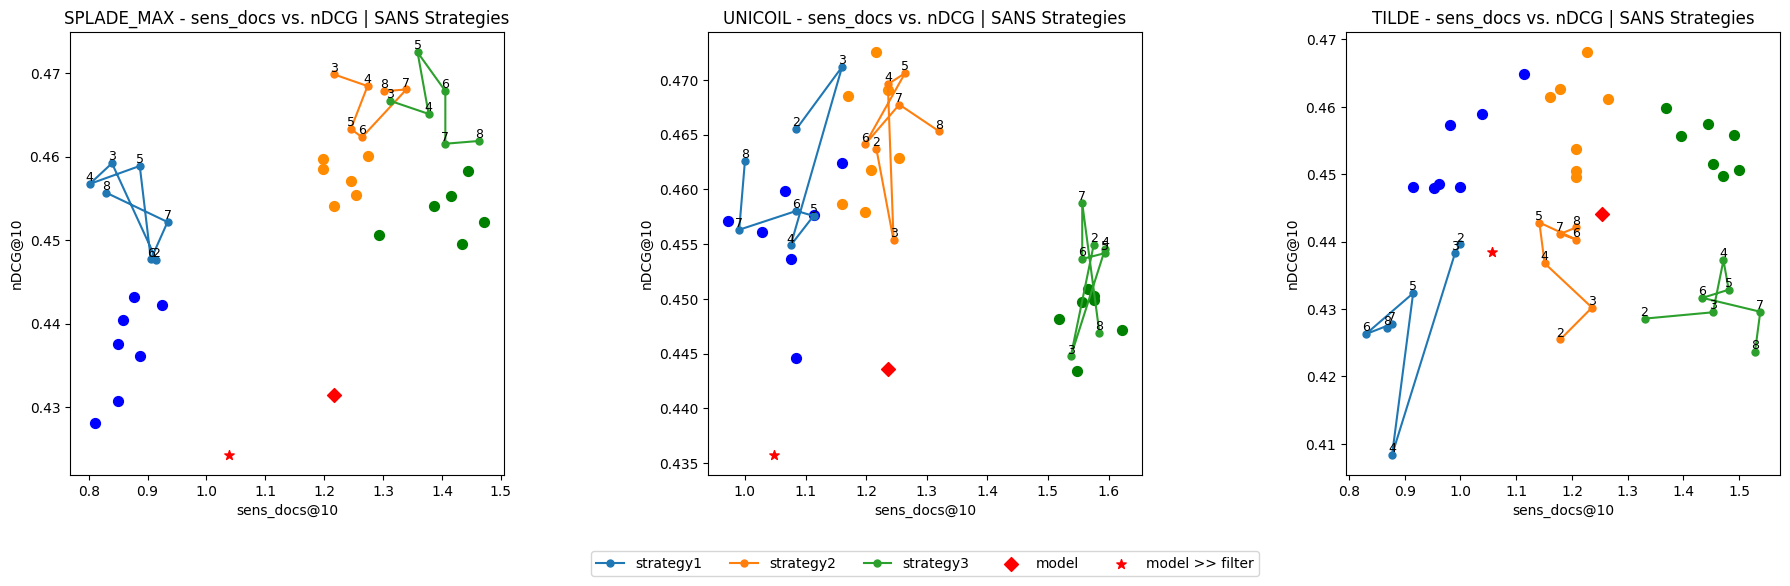

In [13]:
import re
# Define colors for each strategy
strategy_colors = {
    'strategy1': 'blue',
    'strategy2': 'darkorange',
    'strategy3': 'green'
}

# Filter the dataframe by model types
models = ['splade_max', 'unicoil', 'tilde']

# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Loop through each model
for idx, model in enumerate(models):
    # Filter data for the current model
    model_data = retrieval_results[retrieval_results['model'] == model]
    
    # Loop through each strategy and plot
    for strategy in ['strategy1', 'strategy2', 'strategy3']:
        # Filter data for the current strategy
        strategy_data = model_data[model_data['strategy'] == strategy]
        
        # Group the data by the 'group' column, which indicates the group size (e.g., group2, group3, etc.)
        group_sizes = sorted(strategy_data['group'].unique(), key=lambda x: int(x.replace('group', '')))
        
        # Prepare x and y values for plotting
        nDCG_values = []
        sens_docs_values = []
        group_labels = []  # For labeling group sizes

        for group_size in group_sizes:
            group_data = strategy_data[strategy_data['group'] == group_size]
            # Use the raw values for each group size
            nDCG_values.extend(group_data['nDCG@10'].values)
            sens_docs_values.extend(group_data['sens_docs@10'].values)
            group_labels.extend([group_size] * len(group_data))  # Add the group label for each point
        
        # Plot the individual data points for this strategy, colored by the strategy
        axes[idx].plot(sens_docs_values, nDCG_values, label=strategy, marker='o', linestyle='-', markersize=5)

        # Add labels for the group sizes at the x-axis positions
        for i, group_label in enumerate(group_labels):
            group_label = group_label.split("group")[1]
            axes[idx].text(sens_docs_values[i], nDCG_values[i], group_label, fontsize=9, ha='center', va='bottom')
    
    # Add baseline points
    baseline_points = baseline_retrieval_results[baseline_retrieval_results['name'].str.contains(model)]
    for _, row in baseline_points.iterrows():
        # Determine the label (MODEL or MODEL >> FILTER)
        if "filter" in row['name']:
            label = f"model >> filter"
            marker = "*"
        else:
            label = f"model"
            marker = "D"
        
        # Plot the baseline point
        axes[idx].scatter(row['sens_docs@10'], row['nDCG@10'], color='red', marker=marker, s=50, label=label)
        
    # Add rq2 points with strategy color
    rq2_points = rq2_retrieval_results[rq2_retrieval_results['name'].str.contains(model)]
    for _, row in rq2_points.iterrows():
        # Extract the strategy directly from the 'name' column
        match = re.search(r'strategy(\d)', row['name'])  # Matches 'strategy1', 'strategy2', etc.
        strategy = f'strategy{match.group(1)}' if match else 'unknown'  # Default to 'unknown' if no strategy is found
        color = strategy_colors.get(strategy, 'gray')  # Default to gray if strategy is unknown
        axes[idx].scatter(row['sens_docs@10'], row['nDCG@10'], color=color, marker='o', s=50, label=None)
        
    # Set titles and labels for each subplot
    axes[idx].set_title(f'{model.upper()} - sens_docs vs. nDCG | SANS Strategies')
    axes[idx].set_ylabel('nDCG@10')
    axes[idx].set_xlabel('sens_docs@10')
    # axes[idx].legend(title='Strategy')
    handles, labels = axes[0].get_legend_handles_labels()
    # Combine the legends for baseline, strategy, and rq2 points
    axes[1].legend(handles, labels, title=None, loc='center', bbox_to_anchor=(0.5, -0.2), ncol=5)



# Adjust layout to avoid overlapping
plt.tight_layout()

# Show the plot
# plt.savefig("./test2.png", dpi = 1080)
plt.show()

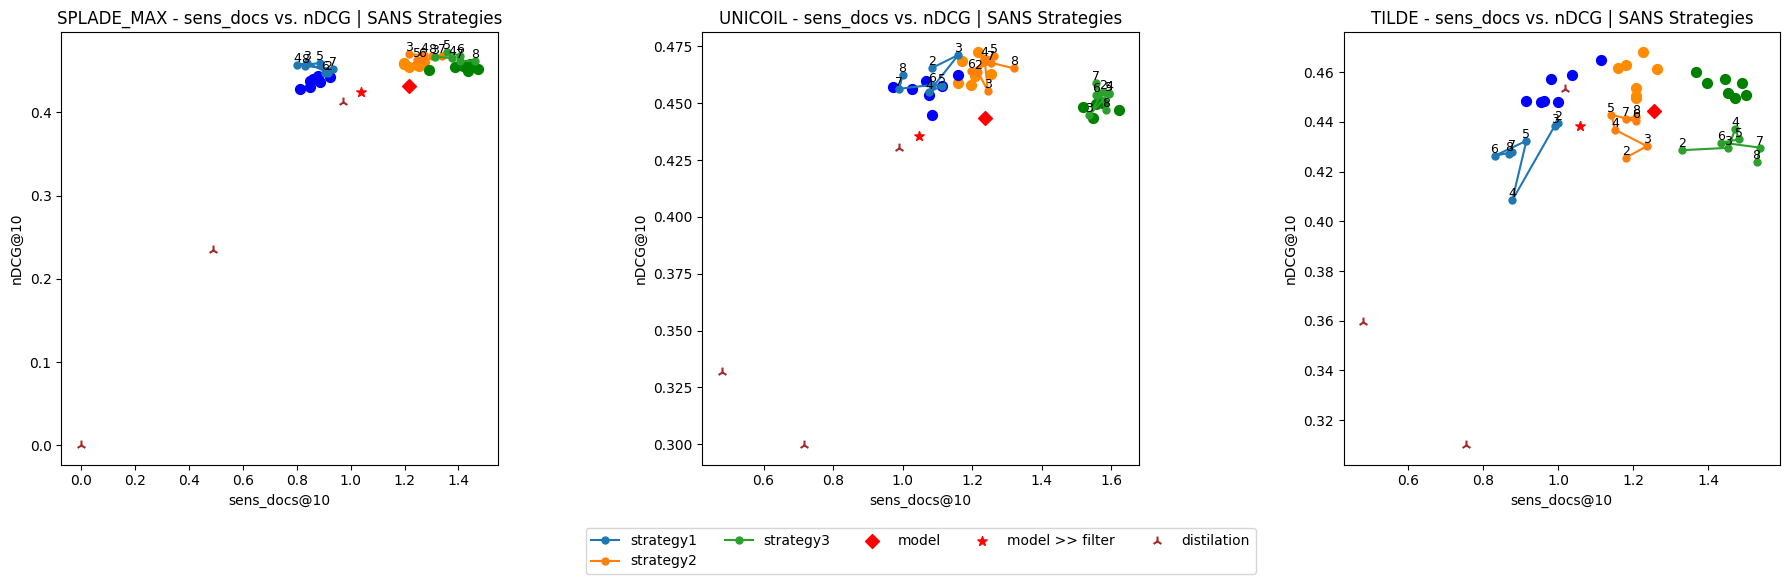

In [15]:
import re
# Define colors for each strategy
strategy_colors = {
    'strategy1': 'blue',
    'strategy2': 'darkorange',
    'strategy3': 'green'
}

# Filter the dataframe by model types
models = ['splade_max', 'unicoil', 'tilde']

# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Loop through each model
for idx, model in enumerate(models):
    # Filter data for the current model
    model_data = retrieval_results[retrieval_results['model'] == model]
    
    # Loop through each strategy and plot
    for strategy in ['strategy1', 'strategy2', 'strategy3']:
        # Filter data for the current strategy
        strategy_data = model_data[model_data['strategy'] == strategy]
        
        # Group the data by the 'group' column, which indicates the group size (e.g., group2, group3, etc.)
        group_sizes = sorted(strategy_data['group'].unique(), key=lambda x: int(x.replace('group', '')))
        
        # Prepare x and y values for plotting
        nDCG_values = []
        sens_docs_values = []
        group_labels = []  # For labeling group sizes

        for group_size in group_sizes:
            group_data = strategy_data[strategy_data['group'] == group_size]
            # Use the raw values for each group size
            nDCG_values.extend(group_data['nDCG@10'].values)
            sens_docs_values.extend(group_data['sens_docs@10'].values)
            group_labels.extend([group_size] * len(group_data))  # Add the group label for each point
        
        # Plot the individual data points for this strategy, colored by the strategy
        axes[idx].plot(sens_docs_values, nDCG_values, label=strategy, marker='o', linestyle='-', markersize=5)

        # Add labels for the group sizes at the x-axis positions
        for i, group_label in enumerate(group_labels):
            group_label = group_label.split("group")[1]
            axes[idx].text(sens_docs_values[i], nDCG_values[i], group_label, fontsize=9, ha='center', va='bottom')
    
    # Add baseline points
    baseline_points = baseline_retrieval_results[baseline_retrieval_results['name'].str.contains(model)]
    for _, row in baseline_points.iterrows():
        # Determine the label (MODEL or MODEL >> FILTER)
        if "filter" in row['name']:
            label = f"model >> filter"
            marker = "*"
        else:
            label = f"model"
            marker = "D"
        
        # Plot the baseline point
        axes[idx].scatter(row['sens_docs@10'], row['nDCG@10'], color='red', marker=marker, s=50, label=label)

    # Add distilation points
    distilation_points = rq3_retrieval_results[rq3_retrieval_results['name'].str.contains(model)]
    axes[idx].scatter(distilation_points['sens_docs@10'], distilation_points['nDCG@10'], color='brown', marker="2", s=50, label="distilation")
    # for _, row in distilation_points.iterrows():
    #     # Plot the baseline point
    #     axes[idx].scatter(row['sens_docs@10'], row['nDCG@10'], color='brown', marker="2", s=50, label="distilation")
        
    # Add rq2 points with strategy color
    rq2_points = rq2_retrieval_results[rq2_retrieval_results['name'].str.contains(model)]
    for _, row in rq2_points.iterrows():
        # Extract the strategy directly from the 'name' column
        match = re.search(r'strategy(\d)', row['name'])  # Matches 'strategy1', 'strategy2', etc.
        strategy = f'strategy{match.group(1)}' if match else 'unknown'  # Default to 'unknown' if no strategy is found
        color = strategy_colors.get(strategy, 'gray')  # Default to gray if strategy is unknown
        axes[idx].scatter(row['sens_docs@10'], row['nDCG@10'], color=color, marker='o', s=50, label=None)
        
    # Set titles and labels for each subplot
    axes[idx].set_title(f'{model.upper()} - sens_docs vs. nDCG | SANS Strategies')
    axes[idx].set_ylabel('nDCG@10')
    axes[idx].set_xlabel('sens_docs@10')
    # axes[idx].legend(title='Strategy')
    handles, labels = axes[0].get_legend_handles_labels()
    # Combine the legends for baseline, strategy, and rq2 points
    axes[1].legend(handles, labels, title=None, loc='center', bbox_to_anchor=(0.5, -0.2), ncol=5)



# Adjust layout to avoid overlapping
plt.tight_layout()

# Show the plot
plt.savefig("../plots/rq3.pdf", dpi = 1080)
plt.show()